## Polynomial Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'Y dataset')

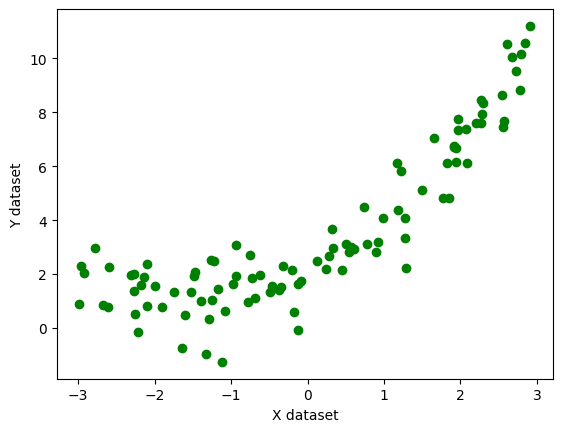

In [2]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1) # quadratic equation used
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
## Lets implement simple regression
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()

In [5]:
regression_1.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
from sklearn.metrics import r2_score
score = r2_score(y_test,regression_1.predict(X_test))
print(score)

0.6572264499998555


Text(0, 0.5, 'Y Dataset')

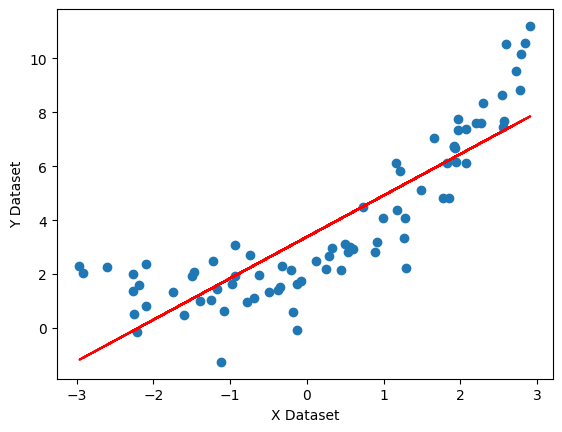

In [7]:
## lets visualize
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X Dataset")
plt.ylabel("Y Dataset")

In [8]:
## Lets apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [9]:
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [10]:
X_train_poly

array([[ 1.00000000e+00, -3.46629490e-01,  1.20152003e-01],
       [ 1.00000000e+00,  1.65930666e+00,  2.75329859e+00],
       [ 1.00000000e+00, -6.21677250e-01,  3.86482603e-01],
       [ 1.00000000e+00,  1.91487598e+00,  3.66675000e+00],
       [ 1.00000000e+00, -1.07620960e+00,  1.15822711e+00],
       [ 1.00000000e+00,  2.91400887e+00,  8.49144770e+00],
       [ 1.00000000e+00,  2.56438869e+00,  6.57608938e+00],
       [ 1.00000000e+00,  1.93671941e+00,  3.75088207e+00],
       [ 1.00000000e+00,  1.96595007e+00,  3.86495969e+00],
       [ 1.00000000e+00, -8.20248388e-02,  6.72807419e-03],
       [ 1.00000000e+00,  2.83833892e+00,  8.05616782e+00],
       [ 1.00000000e+00, -4.96317283e-01,  2.46330845e-01],
       [ 1.00000000e+00,  6.03441354e-01,  3.64141467e-01],
       [ 1.00000000e+00, -2.92292123e+00,  8.54346850e+00],
       [ 1.00000000e+00,  2.07636599e+00,  4.31129572e+00],
       [ 1.00000000e+00,  2.29095058e+00,  5.24845458e+00],
       [ 1.00000000e+00, -2.96494805e+00

In [11]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test, y_pred)
print(score)

0.8824232603038424


In [12]:
print(regression.coef_)

[[0.         1.36857176 0.50012875]]


In [13]:
print(regression.intercept_)

[2.03166021]


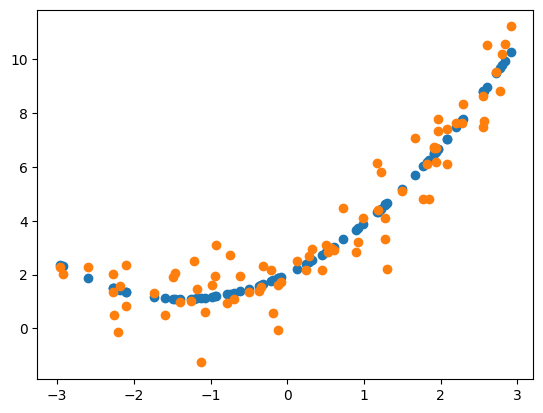

In [14]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [15]:
poly=PolynomialFeatures(degree=3,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [16]:
X_test_poly

array([[  1.        ,  -1.26085824,   1.5897635 ,  -2.00446641],
       [  1.        ,  -0.72059647,   0.51925928,  -0.3741764 ],
       [  1.        ,  -1.64100565,   2.69289956,  -4.41906341],
       [  1.        ,  -2.30844637,   5.32892462, -12.30153668],
       [  1.        ,   2.27730689,   5.18612669,  11.81040206],
       [  1.        ,  -2.77699556,   7.71170435, -21.41536875],
       [  1.        ,   0.32356141,   0.10469198,   0.03387429],
       [  1.        ,  -1.90647193,   3.63463523,  -6.92933004],
       [  1.        ,  -1.52852876,   2.33640016,  -3.57125484],
       [  1.        ,  -2.13592425,   4.56217242,  -9.74445473],
       [  1.        ,  -2.67765203,   7.16982041, -19.19828422],
       [  1.        ,  -1.99106828,   3.96435291,  -7.89329735],
       [  1.        ,   2.26444631,   5.1277171 ,  11.61144008],
       [  1.        ,   2.67204463,   7.13982251,  19.07792442],
       [  1.        ,  -2.98286053,   8.89745697, -26.53987325],
       [  1.        ,  -2

In [17]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test, y_pred)
print(score)

0.8856711830424031


In [18]:
## prediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)


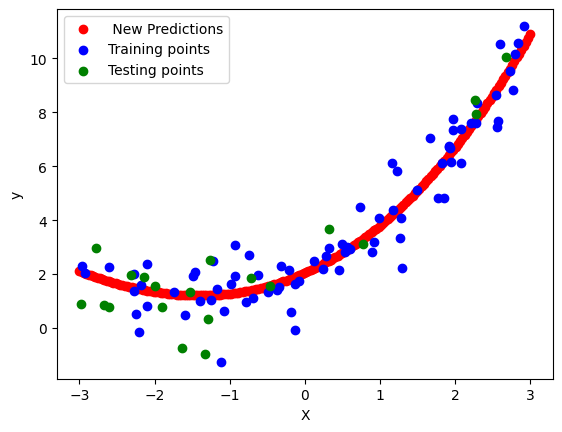

In [19]:
y_new = regression.predict(X_new_poly)
plt.scatter(X_new, y_new, color='r', label=' New Predictions')
plt.scatter(X_train, y_train, color='b', label='Training points')
plt.scatter(X_test, y_test, color='g', label='Testing points')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

## Pipline Concepts

In [20]:
from sklearn.pipeline import Pipeline

In [ ]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)

    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([
        ("poly_features", poly_features),
        ("lin_reg", lin_reg)
    ])
    poly_regression.fit(X_train,y_train)  ## polynomial and fit of linear regression
    y_pred_new = poly_regression.predict(X_new)

    ## plotting prediction line
    plt.scatter(X_new, y_pred_new, color='r', label='Degree' + str(degree), linewidth=3)
    plt.scatter(X_train, y_train, color='b', linewidth=3)
    plt.scatter(X_test, y_test, color='g', linewidth=3)
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend(loc='upper left')
    plt.axis([-4,4,0,10])
    plt.show()

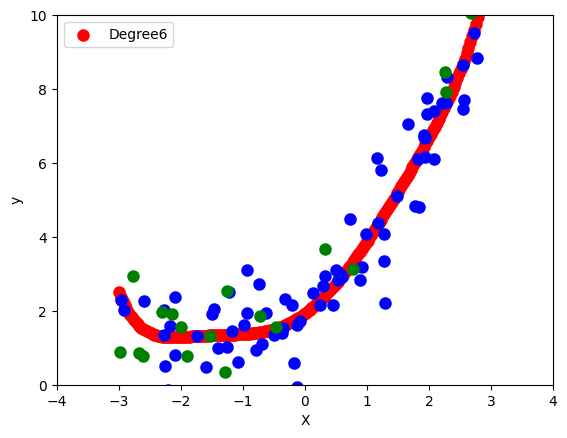

In [28]:
poly_regression(6)